In [41]:
import sys
import os
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import json
import numpy as np
import time
import re
from ftfy import fix_text
import pickle


To do:

* Systematically check if publisher is the same or different

* Use 80% threshhold with new method

In [43]:
df_articles = pd.read_pickle("../../data/processed/duplicates_analysis_80.pkl")

In [46]:
df_duplicates = df_articles[df_articles['near_duplicates_new']]
df_duplicates.shape

(3414, 15)

For each item in df_duplicates, get corresponding original, and compare titles.

In [69]:
def clean_publisher(publisher):

    return publisher.lower().replace("the ", "").replace("blogs", "").replace("(pennsylvania)", " ").strip(' ')

In [81]:
df_articles["publisher_clean"] = df_articles["publisher"].apply(clean_publisher)

In [78]:
count = 0
pairs = []
for index, row in df_duplicates.iterrows():
    publisher_duplicate = clean_publisher(row['publisher'])
    index_original = int(row['near_duplicates_new_index'])
    original_article = df_articles.iloc[index_original]
    publisher_original = clean_publisher(original_article['publisher'])
    if publisher_duplicate != publisher_original:
        count+= 1
        pairs.append(tuple({publisher_duplicate, publisher_original}))
        #break
print(count)

90


In [79]:
set(pairs)

{('dayton daily news (ohio)', 'usa today'),
 ('new york times', 'dayton daily news (ohio)'),
 ('pittsburgh post-gazette', 'new york times'),
 ('pittsburgh post-gazette', 'philadelphia inquirer')}

In [61]:
print(row['title'])

print(original_article['title'])

GOP lawmakers peppered about Russia; Constituents at town halls vent about Trump ties
GOP lawmakers peppered about Russia; Constituents at town halls vent about Trump ties; NEWS ANALYSIS


In [63]:
original_article['body'][:2000]



'A crowd gathers at the Montana State Capitol in Helena after GOP Sen. Steve Daines canceled a speech before Montana lawmakers Tuesday. The protesters had demanded a town hall meeting.\nRep. Taylor\nRepublicans representing GOP-dominated states and congressional districts are being challenged by constituents about Russia and, in some cases, whether they support an independent investigation into President Trump\'s possible ties to the country.\nA USA TODAY analysis of local news coverage from Montana to Virginia found several instances of voters pressing Republican lawmakers on Russia, in addition to Obamacare and immigration restrictions.\nRep. Martha McSally of Arizona was asked to support a "formal congressional investigation" into Trump\'s business interests, namely in Russia, to which she said she\'d "give it a look."\nRep. Tom Reed, who represents a rural, working-class district on the southwest tip of New York, was peppered by constituents during his first town hall at a senior c

In [64]:
row['body'][:2000]


'Republicans representing GOP-dominated states and congressional districts are being challenged by constituents about Russia and, in some cases, whether they support an independent investigation into President Trump\'s  possible ties to the country.\nA USA TODAY analysis of local news coverage from Montana to Virginia found several instances of voters pressing Republican lawmakers on Russia, in addition to  Obamacare and immigration restrictions.\nRep. Martha McSally of Arizona  was asked to support a "formal congressional investigation" into Trump\'s business interests, namely in Russia, to which she said she\'d "give it a look."\nRep. Tom Reed, who represents a rural, working-class district on the southwest tip of New York, was peppered by  constituents during his first town hall at a senior center, with one exchange turning testy as Reed said he hadn\'t seen enough evidence to merit a formal  inquiry. Some in the crowd yelled "What are you covering up?" and "Russia!" as the woman ca

In [65]:
row['publisher']

'USA TODAY'

In [49]:
publisher_duplicate

'The New York Times '

In [3]:
df_articles.head()

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,exact_duplicate,title_stand,near_duplicate_matching_title,duplicate_of_index_90,near_duplicates_new,near_duplicates_new_index
0,Fleece of the Century; On Boxing,The New York Times,2017-08-27,SPORTS,1958 words,LAS VEGAS — The world finally had the two of t...,False,False,NYT/22.DOCX,False,fleece of the century on boxing,False,NaN,False,NaN
1,Ruling Adds to the Risk Of a Monopoly on Power,The New York Times,2019-06-28,Section A; Column 0; National Desk; Pg. 14,1472 words,"At some point or another over the last decade,...",False,False,NYT/22.DOCX,False,ruling adds to the risk of a monopoly on power,False,NaN,False,NaN
2,Gerrymandering and the Rising Risk of a Monopo...,The New York Times,2019-06-28,UPSHOT,1483 words,"At some point or another over the last decade,...",False,False,NYT/22.DOCX,False,gerrymandering and the rising risk of a monopo...,False,NaN,True,1.0
3,How Republicans Can Make a Deal on Health Care...,The New York Times,2017-10-27,OPINION,945 words,A consensus is emerging on Capitol Hill about ...,False,False,NYT/22.DOCX,False,how republicans can make a deal on health care...,False,NaN,False,NaN
4,Harvard Suit Shows Edge Given to Elite In Recr...,The New York Times,2018-11-03,Section A; Column 0; National Desk; Pg. 16,1245 words,"BOSTON -- For the past three weeks, a successi...",False,False,NYT/22.DOCX,False,harvard suit shows edge given to elite in recr...,False,NaN,False,NaN


In [4]:
df_articles['near_duplicates_new'].sum()

np.int64(3235)

In [5]:
df_articles['near_duplicate_matching_title'].sum()

np.int64(1867)

In [6]:
df_articles.loc[(df_articles['near_duplicates_new']) | (df_articles['near_duplicate_matching_title'])].shape[0]

3341

In [7]:
new_duplicates_df = df_articles.loc[df_articles['near_duplicates_new'].apply(lambda x: str(x) == "True")]
new_duplicates_df.head()

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,exact_duplicate,title_stand,near_duplicate_matching_title,duplicate_of_index_90,near_duplicates_new,near_duplicates_new_index
2,Gerrymandering and the Rising Risk of a Monopo...,The New York Times,2019-06-28,UPSHOT,1483 words,"At some point or another over the last decade,...",False,False,NYT/22.DOCX,False,gerrymandering and the rising risk of a monopo...,False,NaN,True,1.0
9,Fleece of the Century,The New York Times,2017-08-28,Section D; Column 0; Sports Desk; Pg. 1; ON BO...,1798 words,LAS VEGAS -- The world finally had the two of ...,False,False,NYT/22.DOCX,False,fleece of the century,False,NaN,True,0.0
33,Photographs of Desperate Shadows Cast by the C...,The New York Times,2016-10-14,ARTS; design,1678 words,Concealed by bedraggled vegetation alongside a...,False,False,NYT/22.DOCX,False,photographs of desperate shadows cast by the c...,False,NaN,True,14.0
43,Infrastructure Is Not Just Roads,The New York Times,2017-06-09,Section A; Column 0; Editorial Desk; Pg. 27; O...,867 words,I once missed a job interview in Watts because...,False,False,NYT/22.DOCX,False,infrastructure is not just roads,False,NaN,True,40.0
46,'Alex Strangelove': Boy Meets Boy. Awkwardness...,The New York Times,2018-05-18,ARTS,1048 words,The writer-director Craig Johnson first came t...,False,False,NYT/22.DOCX,False,alex strangelove boy meets boy awkwardness ens...,False,NaN,True,30.0


In [8]:
ex_number = 0
index_duplicate = new_duplicates_df.index[ex_number]
index_original = new_duplicates_df.near_duplicates_new_index.iloc[ex_number]

duplicate_article = df_articles.iloc[index_duplicate ]
original_article = df_articles.iloc[int(index_original) ]

In [9]:
duplicate_article["publisher"]

'The New York Times '

In [10]:
original_article["publisher"]

'The New York Times'

In [11]:
print(f"Title 1: {duplicate_article['title']}\n\nTitle 2: {original_article['title']}")

Title 1: Gerrymandering and the Rising Risk of a Monopoly on Power

Title 2: Ruling Adds to the Risk Of a Monopoly on Power


In [12]:
print("Body 1:\n\n", duplicate_article['body'][:2000])

Body 1:

 At some point or another over the last decade, Democrats have won the most votes but lost national elections for the presidency, the House and the Senate.
Partisan gerrymandering is just one of the reasons the Democrats are at such a disadvantage. But the Supreme Court's decision on gerrymandering Thursday came as long-term political and demographic trends threaten to put Democrats at an even greater disadvantage in the Senate and perhaps also the presidency.
It's even possible to imagine a future in which Republicans could effectively claim a monopoly on federal power despite continued weakness in the national vote.
Sustained minority rule — within the bounds of the Constitution — is not an imminent peril. After all, Democrats recaptured the House in November despite partisan gerrymandering. But the risk is real, and even if it does not materialize it might strain American democracy.
So on one hand, the ruling — which said federal courts can't bar partisan gerrymandering — m

In [13]:
print("Body 2:\n\n", original_article['body'][:2000])

Body 2:

 At some point or another over the last decade, Democrats have won the most votes but lost national elections for the presidency, the House and the Senate.
Partisan gerrymandering is just one of the reasons the Democrats are at such a disadvantage. But the Supreme Court's decision on gerrymandering Thursday came as long-term political and demographic trends threaten to put Democrats at an even greater disadvantage in the Senate and perhaps also the presidency. 
  It's even possible to imagine a future in which Republicans could effectively claim a monopoly on federal power despite continued weakness in the national vote.
  Sustained minority rule -- within the bounds of the Constitution -- is not an imminent peril. After all, Democrats recaptured the House in November despite partisan gerrymandering. But the risk is real, and even if it does not materialize it might strain American democracy.
  So on one hand, the ruling -- which said federal courts can't bar partisan gerryman

Old duplicate but not new duplicate:

In [14]:
df_old_but_not_new = df_articles.loc[(~df_articles['near_duplicates_new']) & (df_articles['near_duplicate_matching_title'])]
print("Number of cases resulting in duplicate match in old method but not new method: ", df_old_but_not_new.shape[0])
ex_number = 0
index_duplicate = df_old_but_not_new.index[ex_number]
index_original = df_old_but_not_new.duplicate_of_index_90.iloc[ex_number]

duplicate_article = df_articles.iloc[index_duplicate ]
original_article = df_articles.iloc[int(index_original) ]

Number of cases resulting in duplicate match in old method but not new method:  106


In [15]:
print(f"Title 1: {duplicate_article['title']}\n\nTitle 2: {original_article['title']}")

Title 1: Movie guide

Title 2: Movie guide


In [16]:
print("Body 1:\n\n", duplicate_article['body'][:2000])

Body 1:

 Four stars: superior. Three: good. Two: average. One: poor. D (drugs), L (language), N (nudity), S (sexual content), V (violence). Ratings by Film Critic Dann Gire, unless otherwise noted; AP (Associated Press), WP (Washington Post). Picks "Air" — Director Ben Affleck's funny, moving and surprisingly meaningful tale of how Nike came to create Air Jordan basketball shoes might have been a real snore. 
Working from a well-judged script and enlisting a superb cast of appealing ensemble players (Matt Damon, Viola Davis, Jason Bateman, Chris Tucker, Affleck), he has created a smart, entertaining movie that shoots and scores. WP. (R) L. 112 minutes. ? ? ? "Are You There God? It's Me, Margaret." — For five decades, celebrated author Judy Blume refused to sell the movie rights to her controversial novel, a frank account of a young girl struggling to understand an unfair world and her combined fear/excitement at the prospect of becoming a woman. Luckily for audiences, Blume let filmma

In [17]:
print("Body 2:\n\n", original_article['body'][:2000])

Body 2:

 Movie guide Four stars: superior. Three: good. Two: average. One: poor. D (drugs), L (language), N (nudity), S (sexual content), V (violence). Ratings by Film Critic Dann Gire, unless otherwise noted; AP (Associated Press), WP (Washington Post). Picks "Air" — Director Ben Affleck's funny, moving and surprisingly meaningful tale of how Nike came to create Air Jordan basketball shoes might have been a snore. 
Working from a well-judged script and enlisting a superb cast of appealing ensemble players (Matt Damon, Viola Davis, Jason Bateman, Chris Tucker, Affleck), he has created a smart, entertaining movie that shoots and scores. WP. (R) L. 112 minutes. ? ? ? "Are You There God? It's Me, Margaret." — For five decades, celebrated author Judy Blume refused to sell the movie rights to her controversial novel, a frank account of a young girl struggling to understand an unfair world and her combined fear/excitement at the prospect of becoming a woman. Luckily for audiences, Blume let

# Duplicates

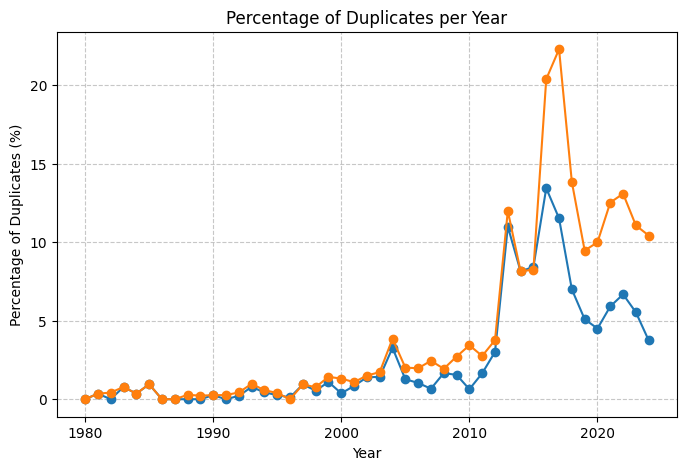

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
df_articles['date'] = pd.to_datetime(df_articles['date'])

# Extract year
df_articles['year'] = df_articles['date'].dt.year

# Group by year and calculate percentage of duplicates
dup_stats_old_method = df_articles.groupby('year')['near_duplicate_matching_title'].mean() * 100

# Group by year and calculate percentage of duplicates
dup_stats_new_method = df_articles.groupby('year')['near_duplicates_new'].mean() * 100


# Plot
plt.figure(figsize=(8,5))
plt.plot(dup_stats_old_method.index, dup_stats_old_method.values, marker='o')
plt.plot(dup_stats_new_method.index, dup_stats_new_method.values, marker='o')
plt.title("Percentage of Duplicates per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Duplicates (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [19]:
df_articles_80 = pd.read_pickle("../../data/processed/duplicates_analysis_80.pkl")

# Ensure date column is datetime
df_articles_80['date'] = pd.to_datetime(df_articles_80['date'])

# Extract year
df_articles_80['year'] = df_articles_80['date'].dt.year


In [20]:
df_articles_80['near_duplicates_new'].sum()

np.int64(3414)

In [21]:
df_articles['near_duplicates_new'].sum()

np.int64(3235)

In [22]:
df_old_but_not_new = df_articles_80.loc[(~df_articles_80['near_duplicates_new']) & (df_articles_80['near_duplicate_matching_title'])]
print("Number of cases resulting in duplicate match in old method but not new method: ", df_old_but_not_new.shape[0])

Number of cases resulting in duplicate match in old method but not new method:  41


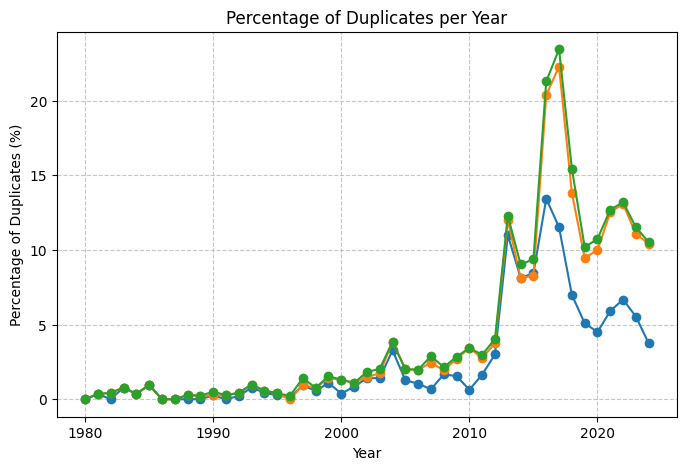

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
df_articles['date'] = pd.to_datetime(df_articles['date'])

# Extract year
df_articles['year'] = df_articles['date'].dt.year

# Group by year and calculate percentage of duplicates
dup_stats_old_method = df_articles.groupby('year')['near_duplicate_matching_title'].mean() * 100

# Group by year and calculate percentage of duplicates
dup_stats_new_method = df_articles.groupby('year')['near_duplicates_new'].mean() * 100

dup_stats_new_method_80 = df_articles_80.groupby('year')['near_duplicates_new'].mean() * 100


# Plot
plt.figure(figsize=(8,5))
plt.plot(dup_stats_old_method.index, dup_stats_old_method.values, marker='o')
plt.plot(dup_stats_new_method.index, dup_stats_new_method.values, marker='o')
plt.plot(dup_stats_new_method_80.index, dup_stats_new_method_80.values, marker='o')
plt.title("Percentage of Duplicates per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Duplicates (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


75 threshold

In [25]:
df_articles_75 = pd.read_pickle("../../data/processed/duplicates_analysis_75.pkl")

# Ensure date column is datetime
df_articles_75['date'] = pd.to_datetime(df_articles_75['date'])

# Extract year
df_articles_75['year'] = df_articles_75['date'].dt.year


dup_stats_new_method_75 = df_articles_75.groupby('year')['near_duplicates_new'].mean() * 100

In [26]:
df_articles_75['near_duplicates_new'].sum()

np.int64(3448)

In [27]:
df_old_but_not_new = df_articles_75.loc[(~df_articles_75['near_duplicates_new']) & (df_articles_75['near_duplicate_matching_title'])]
print("Number of cases resulting in duplicate match in old method but not new method: ", df_old_but_not_new.shape[0])

Number of cases resulting in duplicate match in old method but not new method:  30


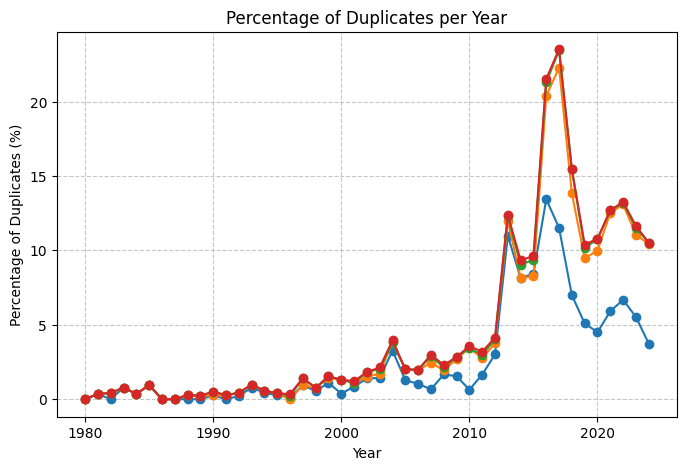

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
df_articles['date'] = pd.to_datetime(df_articles['date'])

# Extract year
df_articles['year'] = df_articles['date'].dt.year

# Group by year and calculate percentage of duplicates
dup_stats_old_method = df_articles.groupby('year')['near_duplicate_matching_title'].mean() * 100

# Group by year and calculate percentage of duplicates
dup_stats_new_method = df_articles.groupby('year')['near_duplicates_new'].mean() * 100

dup_stats_new_method_80 = df_articles_80.groupby('year')['near_duplicates_new'].mean() * 100


# Plot
plt.figure(figsize=(8,5))
plt.plot(dup_stats_old_method.index, dup_stats_old_method.values, marker='o')
plt.plot(dup_stats_new_method.index, dup_stats_new_method.values, marker='o')
plt.plot(dup_stats_new_method_80.index, dup_stats_new_method_80.values, marker='o')
plt.plot(dup_stats_new_method_75.index, dup_stats_new_method_75.values, marker='o')
plt.title("Percentage of Duplicates per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Duplicates (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [29]:
combined_df = pd.concat([df_articles,df_articles_75[['near_duplicates_new', 'near_duplicates_new_index']].rename(columns={'near_duplicates_new': 'near_duplicates_new_75', 'near_duplicates_new_index': 'near_duplicates_new_index_75'})], axis=1)
difference_75_90_new = combined_df.loc[(combined_df['near_duplicates_new_75']) & ~(combined_df['near_duplicates_new'])]

In [30]:
ex_number = 0
index_duplicate = difference_75_90_new.index[ex_number]
index_original = difference_75_90_new.near_duplicates_new_index_75.iloc[ex_number]

duplicate_article = df_articles.iloc[index_duplicate ]
original_article = df_articles.iloc[int(index_original) ]

In [33]:
duplicate_article["publisher"]

'Pittsburgh Post-Gazette'

In [34]:
original_article["publisher"]

'Pittsburgh Post-Gazette'

In [31]:
print(f"Title 1: {duplicate_article["title"]}")
print(f"Title 2: {original_article["title"]}")

Title 1: THE VER-N'AT-CULAR
Title 2: PITTSBURGH VER-N'AT-CULAR


In [35]:
print(f"Body 1 - length: {len(duplicate_article["body"])}")
print(f"Body 2 - length: {len(original_article["body"])}")

Body 1 - length: 4155
Body 2 - length: 4374


In [36]:
print(f"Body 1\n\n: {duplicate_article["body"]}")


Body 1

: Like most childhood indignities, this one was suffered on the playground.
I was 8 years old and we'd just moved from the city to the suburbs. I was playing a game of pickup baseball (Nintendo had not yet wrought havoc on outdoor activities) and at some point during an argument about an out call I let fly a "yinz." An older kid chided me -- "You said yinz! What are you, STUPID??" before shoving me to the ground.
This is the only bullying I endured in my charmed upbringing. But it stuck with me. For years and years, I'd bristle when people poked fun at our Picksburgh patois, our Mon lexicon. Perhaps because I was a child of the '80s and came of age in the '90s -- during decades of decline for my hometown -- I would become defensive, especially while away at college. Yeah, we talk funny. So does your mom.
But long before the New York Times called us the Galapagos Island of dialects and Gawker said we have the ugliest accent in America (have they never heard a Bostonian speak?), 

In [37]:
print(f"Body 2\n\n: {original_article["body"]}")

Body 2

: Like most childhood indignities, this one was suffered on the playground.
I was 8 years old and we'd just moved from the city to the suburbs. I was playing a game of pickup baseball (Nintendo had not yet wrought havoc on outdoor activities) and at some point during an argument about an out call, I let fly a "yinz." An older kid chided me - "You said yinz! What are you, STUPID??" before shoving me to the ground.
This is the only bullying I endured in my charmed upbringing. But it stuck with me. For years and years, I'd bristle when people poked fun at our Picksburgh patois, our Mon lexicon.
Perhaps because I was a child of the '80s and came of age in the '90s - during decades of decline for my hometown - I would become defensive, especially while away at college. Yeah, we talk funny. So does your mom.
But long before The New York Times called us the Galapagos Island of dialects and Gawker said we have the ugliest accent in America (have they never heard a Bostonian speak?), I 

In [39]:
def compute_similarity_simple(text1: str, text2: str) -> float:
    """
    Compute a simple word-overlap similarity score between two texts.
    Uses Jaccard similarity (intersection over union of unique words).

    Args:
        text1 (str): The first article or document.
        text2 (str): The second article or document.

    Returns:
        float: Similarity score between 0 and 1.
    """
    # Convert to lowercase, remove non-alphanumeric, split into words
    tokenize = lambda text: set(re.findall(r'\b\w+\b', text.lower()))

    words1 = tokenize(text1)
    words2 = tokenize(text2)

    if not words1 or not words2:
        return 0.0  # Avoid division by zero

    overlap = len(words1 & words2)
    union = len(words1 | words2)

    return overlap / union

In [40]:
compute_similarity_simple(original_article["body"], duplicate_article["body"])

0.8846153846153846

In [178]:
combined_df

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,exact_duplicate,title_stand,near_duplicate_matching_title,duplicate_of_index_90,near_duplicates_new,near_duplicates_new_index,year,near_duplicates_new_75
0,Fleece of the Century; On Boxing,The New York Times,2017-08-27,SPORTS,1958 words,LAS VEGAS — The world finally had the two of t...,False,False,NYT/22.DOCX,False,fleece of the century on boxing,False,NaN,False,NaN,2017,False
1,Ruling Adds to the Risk Of a Monopoly on Power,The New York Times,2019-06-28,Section A; Column 0; National Desk; Pg. 14,1472 words,"At some point or another over the last decade,...",False,False,NYT/22.DOCX,False,ruling adds to the risk of a monopoly on power,False,NaN,False,NaN,2019,False
2,Gerrymandering and the Rising Risk of a Monopo...,The New York Times,2019-06-28,UPSHOT,1483 words,"At some point or another over the last decade,...",False,False,NYT/22.DOCX,False,gerrymandering and the rising risk of a monopo...,False,NaN,True,1.0,2019,True
3,How Republicans Can Make a Deal on Health Care...,The New York Times,2017-10-27,OPINION,945 words,A consensus is emerging on Capitol Hill about ...,False,False,NYT/22.DOCX,False,how republicans can make a deal on health care...,False,NaN,False,NaN,2017,False
4,Harvard Suit Shows Edge Given to Elite In Recr...,The New York Times,2018-11-03,Section A; Column 0; National Desk; Pg. 16,1245 words,"BOSTON -- For the past three weeks, a successi...",False,False,NYT/22.DOCX,False,harvard suit shows edge given to elite in recr...,False,NaN,False,NaN,2018,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43654,TRUMP WAVE,"Star Tribune (Minneapolis, MN)",2016-11-09,NEWS; Pg. 1A,725 words,Florida was turning red and Rick Rice leaned t...,False,False,Other publishers/Files (500) (11).DOCX,False,trump wave,False,NaN,False,NaN,2016,False
43655,Judge restrains spending of suspected stolen f...,Chicago Daily Herald,1999-02-03,News;,233 words,A DuPage County judge Monday ordered a restrai...,False,False,Other publishers/Files (500) (11).DOCX,False,judge restrains spending of suspected stolen f...,False,NaN,False,NaN,1999,False
43656,"WORLD REACTS TO TRUMP; SHOCK, JOY AND FEAR AS ...",Dayton Daily News (Ohio),2016-11-09,ELECTION UPDATE; Pg. AA1,708 words,"From Virginia coal country, as election result...",False,False,Other publishers/Files (500) (11).DOCX,False,world reacts to trump shock joy and fear as vo...,True,43649.0,True,43649.0,2016,True
43657,The real (surprisingly comforting) reason rura...,Chicago Daily Herald,2019-05-26,BUSINESS; Pg. 0,1425 words,According to the United States' original 1950 ...,False,False,Other publishers/Files (500) (11).DOCX,False,the real surprisingly comforting reason rural ...,False,NaN,False,NaN,2019,False


Other threshhold: 60

In [190]:
df_articles_60 = pd.read_pickle("../../data/processed/duplicates_analysis_60.pkl")

# Ensure date column is datetime
df_articles_60['date'] = pd.to_datetime(df_articles_60['date'])

# Extract year
df_articles_60['year'] = df_articles_60['date'].dt.year


dup_stats_new_method_60 = df_articles_60.groupby('year')['near_duplicates_new'].mean() * 100

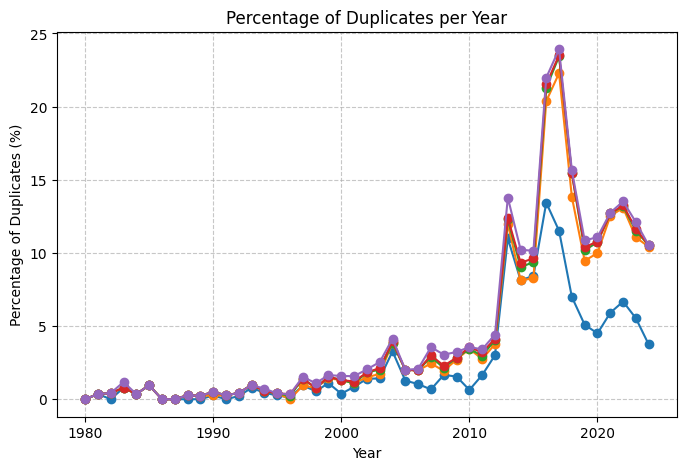

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
df_articles['date'] = pd.to_datetime(df_articles['date'])

# Extract year
df_articles['year'] = df_articles['date'].dt.year

# Group by year and calculate percentage of duplicates
dup_stats_old_method = df_articles.groupby('year')['near_duplicate_matching_title'].mean() * 100

# Group by year and calculate percentage of duplicates
dup_stats_new_method = df_articles.groupby('year')['near_duplicates_new'].mean() * 100


# Plot
plt.figure(figsize=(8,5))
plt.plot(dup_stats_old_method.index, dup_stats_old_method.values, marker='o')
plt.plot(dup_stats_new_method.index, dup_stats_new_method.values, marker='o')
plt.plot(dup_stats_new_method_80.index, dup_stats_new_method_80.values, marker='o')
plt.plot(dup_stats_new_method_75.index, dup_stats_new_method_75.values, marker='o')
plt.plot(dup_stats_new_method_60.index, dup_stats_new_method_60.values, marker='o')
plt.title("Percentage of Duplicates per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Duplicates (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# New Grouped by Publisher Results

In [150]:
df_articles = pd.read_pickle("../../data/processed/duplicates_analysis_test.pkl")

In [151]:
df_articles.shape

(1000, 12)

In [152]:
df_articles.tail()

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,publisher_clean,near_duplicates_new,near_duplicates_new_index
995,We'll be better off with Obamacare than withou...,Chicago Daily Herald,2013-11-19,NEWS; Pg. 8,599 words,\n\nI can hear in my mind's ear Barbra Streisa...,False,False,Other publishers/Files (500) (12).DOCX,chicago daily herald,False,NaN
996,"Early arrivals focus on golf, not protests",USA TODAY,2003-04-07,SPORTS;,275 words,"\nAUGUSTA, Ga. -- The aura and prestige of The...",False,False,Other publishers/Files (500) (12).DOCX,usa today,False,NaN
997,"Middle class wants better government, not a ta...",Dayton Daily News (Ohio),2017-10-01,WASHINGTON POST NATIONAL WEEKLY; Pg. WAPO20,965 words,\n\nOne of the great canards of American polit...,False,False,Other publishers/Files (500) (12).DOCX,dayton daily news (ohio),True,993.0
998,HOW ORMSBY PLAYGROUND SAVED US;\nRICHARD PETER...,Pittsburgh Post-Gazette (Pennsylvania),2005-07-31,"EDITORIAL,",803 words,\n\nI spent a good part of my teen-age years i...,False,False,Other publishers/Files (500) (12).DOCX,pittsburgh post-gazette,False,NaN
999,"U.S. women get gold, men bronze; Kearney trium...",USA TODAY,2010-02-15,BONUS; Pg. 6D,399 words,\n\nVANCOUVER -- In an Olympic world of soarin...,False,False,Other publishers/Files (500) (12).DOCX,usa today,False,NaN


In [137]:
index_original

4723

In [138]:
duplicate_article

title                            Footballer as Life Coach (The Imaginary Kind)
publisher                                                   The New York Times
date                                                                2010-05-14
section                      Section C; Column 0; Movies, Performing Arts/W...
length                                                               731 words
body                         \n\nThere are two Erics in ''Looking for Eric....
correction_appended                                                      False
load_date_at_end                                                         False
source_file                                                        NYT/30.DOCX
publisher_clean                                                 new york times
near_duplicates_new                                                       True
near_duplicates_new_index                                               4723.0
Name: 9963, dtype: object

In [153]:
ex_number = 997

duplicate_article = df_articles.iloc[ex_number]
index_original = int(duplicate_article['near_duplicates_new_index'])

original_article = df_articles.loc[df_articles.index == index_original].iloc[0]

In [154]:
duplicate_article['title']

'Middle class wants better government, not a tax cut; STEVEN PEARLSTEINis a Washington Post business and economics writer. He is also the Robinson professor of public affairs at George Mason University.'

In [155]:
original_article['title']

'Middle class wants better government, not a tax cut; STEVEN PEARLSTEINis a Washington Post business and economics writer. He is also the Robinson professor of public affairs at George Mason University.'

In [156]:
print(duplicate_article['body'][:1000])



One of the great canards of American politics these days is that the “struggling” middle class needs and wants a tax cut. It doesn’t. What it needs and wants after years of tax and spending cuts is more and better government services for the taxes it already pays.
According to the nonpartisan Tax Policy Center, the average rate of income tax paid by the American middle class  the 20 percent of households in the exact middle of the income ladder  has been going down for decades, and was at 2.6 percent of gross income in 2013, the last year for which statistics are available. For the 40 percent of households below them  what you might call the working class  the average household not only paid no tax, but because of refundable tax credits actually got money back from the government equal to 1.2 percent of income, helping to offset payroll taxes (Social Security and Medicare) that averaged around 8 percent. To whatever extent the middle class is struggling, it ain’t because of income ta

In [157]:
print(original_article['body'][:1000])



Treasury Secretary Steven Mnuchin arrives last month at the Capitol for a meeting about an overhaul of the tax code.
One of the great canards of American politics these days is that the "struggling" middle class needs and wants a tax cut. It doesn't. What it needs and wants after years of tax and spending cuts is more and better government services for the taxes it already pays.
According to the nonpartisan Tax Policy Center, the average rate of income tax paid by the American middle class - the 20 percent of households in the exact middle of the income ladder - has been going down for decades, and was at 2.6 percent of gross income in 2013, the last year for which statistics are available. For the 40 percent of households below them - what you might call the working class - the average household not only paid no tax, but because of refundable tax credits actually got money back from the government equal to 1.2 percent of income, helping to offset payroll taxes (Social Security and M

In [148]:
duplicate_article['publisher']

'Dayton Daily News (Ohio)'

In [149]:
original_article['publisher']

'Dayton Daily News (Ohio)'

In [123]:
duplicate_article['near_duplicates_new'] is np.True_

True

In [126]:
df_articles.loc[df_articles['near_duplicates_new']]

,title,publisher,date,section,length,body,correction_appended,load_date_at_end,source_file,publisher_clean,near_duplicates_new,near_duplicates_new_index
2,Gerrymandering and the Rising Risk of a Monopo...,The New York Times,2019-06-28,UPSHOT,1483 words,\n\nAt some point or another over the last dec...,False,False,NYT/22.DOCX,new york times,True,1.0
9,Fleece of the Century,The New York Times,2017-08-28,Section D; Column 0; Sports Desk; Pg. 1; ON BO...,1798 words,\n\nLAS VEGAS -- The world finally had the two...,False,False,NYT/22.DOCX,new york times,True,0.0
33,Photographs of Desperate Shadows Cast by the C...,The New York Times,2016-10-14,ARTS; design,1678 words,\n\nConcealed by bedraggled vegetation alongsi...,False,False,NYT/22.DOCX,new york times,True,14.0
43,Infrastructure Is Not Just Roads,The New York Times,2017-06-09,Section A; Column 0; Editorial Desk; Pg. 27; O...,867 words,\n\nI once missed a job interview in Watts bec...,False,False,NYT/22.DOCX,new york times,True,40.0
46,‘Alex Strangelove’: Boy Meets Boy. Awkwardness...,The New York Times,2018-05-18,ARTS,1048 words,\n\nThe writer-director Craig Johnson first ca...,False,False,NYT/22.DOCX,new york times,True,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9867,"After Trump's Win, an Anxious Mexico Asks: Wha...",The New York Times,2016-11-14,WORLD; americas,1479 words,\n\nMEXICO CITY - Ever since the election of ...,False,False,NYT/30.DOCX,new york times,True,9845.0
9868,Storm With ‘No Boundaries’ Took Aim at Rich an...,The New York Times,2017-08-31,US,1689 words,"\n\nHOUSTON — Antonio Armenta paid $45,000 for...",False,False,NYT/30.DOCX,new york times,True,9851.0
9881,The Trouble With Hollywood’s Gender Flips; Cri...,The New York Times,2018-06-12,MOVIES,2112 words,"\n\nBack in the summer of 2016, when the femal...",False,False,NYT/30.DOCX,new york times,True,9847.0
9892,Lifting Voices and Spirits Is a Choirmaster's ...,The New York Times,2010-07-07,Section C; Column 0; The Arts/Cultural Desk; P...,657 words,\n\n''The Choir'' was so popular and acclaimed...,False,False,NYT/30.DOCX,new york times,True,9873.0
